# Tutorial

Time to simulate $n$ steps: $\mathcal{O}(n)$ \
Memory simulation: $\mathcal{O}(n)$ \
Time analysis: $\mathcal{O}(n)$ \
Memory analysis: $\mathcal{O}(n)$ \
Time number fluorophores $n$: $\mathcal{O}(n)$ \
Check with %%time and %memit

### Naming convention
|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|
|resample|frame integration time|

Modules that are not directly shown in tutorial: 
- formulas.py - most of it is used to automatically determine transition rates
- distributions.py - mainly to describe intensity distributions
- figure.py - used indirectly in most plotting routines
- fluo_data.py - used indirectly in fluorophores.py
- network.py - used indirectly in transitions.py and simulation.py

In [23]:
import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

import warnings
def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache
        line = linecache.getline(filename, lineno)
    return f'WARNING for line: {line} {msg} \n' 
warnings.formatwarning = custom_warning_format


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup the fluorophore system
fluorophores.py

Attributes of Fluorophore:
.................................................................
identity = None
_________________________________________________________________
name = 'cy5'
_________________________________________________________________
position = array([0, 4])
_________________________________________________________________
constants = Cy5(data_files='cy5_data', MAXIMUM_EXTINCTION_CO... H2O_ATTACK_S=0, H2O_ATTACK_T=0, BACK_REACTION=0)
_________________________________________________________________


Attributes of FluorophoreSystem:
.................................................................
fluorophores = [Fluorophore(identity=0, name='cy5', position=arr...H2O_ATTACK_S=0, H2O_ATTACK_T=0, BACK_REACTION=0)), Fluorophore(identity=1, name='cy5', position=arr...H2O_ATTACK_S=0, H2O_ATTACK_T=0, BACK_REACTION=0)), Fluorophore(identity=2, name='atto643', position...CK_S=30000.0, H2O_ATTACK_T=0, BACK_REACTION=0.1))]
_____________________________________________________

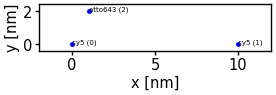

In [24]:
# Method 1: define the positions freely
fluorophore_1 = fl.Fluorophore(name='cy5', position=[0, 4])
fluorophore_2 = fl.Fluorophore(name='cy5', position=[4.5, 3])
fluorophores = [fluorophore_1, fluorophore_2]

# Method 2: collection of fluorophores in a certain shape
fluorophores = fl.construct_fluorophores(name='cy5', distance=10, count=2, shape='square')
fluorophores.append(fl.Fluorophore(name='atto643', position=[1, 2]))

mi.print_class(fluorophore_1, 'Fluorophore')

# FluorophoreSystem only takes the collection of fluorophores as parameter
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

mi.print_class(fluorophore_system, 'FluorophoreSystem')

fluorophore_system.plot(scale=0.5, quadratic=True);

### Photophysical states
transitions.py

In [25]:
# lists all photophysical states and their corresponding identifier
print('photophysical state and identifier:')
for single_state in tr.SingleState:
    print(single_state.name, single_state.value)

photophysical state and identifier:
S0 0
S1 1
S2 2
T1 3
T2 4
B 5
Cis 6
OFF1 7
OFF2 8


### Setup a transition
transitions.py

In [26]:
# each Transition involves some single or paired (energy transfer) photophysical states
s0 = tr.SingleState.S0
s0_s1 = tr.PairedState.S0_S1

print(f'{s0 = }\n{s0.value = }\n{s0_s1 = }\n{s0_s1.single_state_values = }\n' +
      f'{s0_s1.acceptor = }\n{s0_s1.donor = }\n')

# each Transition is of a certain TransitionType
transition_type = tr.TransitionType.EXCITATION

mi.print_class(transition_type.value, 'TransitionType')

# initializing a transition
transition = tr.Transition(transition_type=transition_type, rate=1e6, 
                           fluorophore_ids=[1])

mi.print_class(transition, 'Transition')


s0 = <SingleState.S0: 0>
s0.value = 0
s0_s1 = <PairedState.S0_S1: [<SingleState.S0: 0>, <SingleState.S1: 1>]>
s0_s1.single_state_values = (0, 1)
s0_s1.acceptor = <SingleState.S1: 1>
s0_s1.donor = <SingleState.S0: 0>

Attributes of TransitionType:
.................................................................
abbreviation = 'EXC'
_________________________________________________________________
initial_state = <SingleState.S0: 0>
_________________________________________________________________
final_state = <SingleState.S1: 1>
_________________________________________________________________
photon = False
_________________________________________________________________


Attributes of Transition:
.................................................................
identity = None
_________________________________________________________________
transition_type = <TransitionType.EXCITATION: TransitionAttributes..., final_state=<SingleState.S1: 1>, photon=False)>
______________________

### Setup the transition set
transitions.py

Attributes of TransitionSet:
.................................................................
fluorophore_system = FluorophoreSystem(fluorophores=[Fluorophore(iden...K_T=0, BACK_REACTION=0))], distances={}, count=1)
_________________________________________________________________
transition_df[:6] =                                              transition_type abbreviation  \
Fluorophore identity                                                        
cy5         0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST        ISCST   
            3         TransitionType.INTERSYSTEM_CROSSING_TS        ISCTS   
            4                   TransitionType.ISOMERIZATION          ISO   
            5               TransitionType.BACKISOMERIZATION         BISO   

                        initial_state      final_state          rate  photon  \


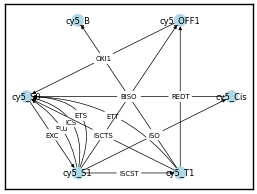

In [45]:
# Method 1: define the transitions freely
transition_1 = tr.Transition(tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0])
transition_2 = tr.Transition(tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, fluorophore_ids=[0])
transition_3 = tr.Transition(tr.TransitionType.FRET, rate=4e6, fluorophore_ids=[(0, 1)])
transitions = {'cy5': [transition_1, transition_2],
               'D: cy5, A: cy5, dist: 10.0': [transition_3]}

# Method 2: load a transition set, if available
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=True, energy_transfer=True,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)

transition_set = tr.TransitionSet(transitions, fluorophore_system)

# the transition_set can be easily modified with the following methods
transition_set_no_bleaching = transition_set.remove_absorbing_states()
transition_set_no_ets = transition_set.remove_absorbing_states()
transition_set_adj = transition_set.adjust_rates(change_dict={1: 1e3})
transition_set_filtered = transition_set.filter_by_identity(remove_list=[6])

# if everything is set, finalize TransitionSet
transition_set.finalize()

mi.print_class(transition_set, 'TransitionSet')

transition_set.plot(graph_type='shell', colors=None, scale=0.5);

### Predict some statistics of the Markov chain
prediction.py

Rules for prediction:
- if energy transfers, pairs have separate color in plot but are normalized with other transitions of their donor
- absorbing states: the prediction works using the fundamental matrix. For Q, the transitions leading to an OVERALL absorbed state are dropped. This can be done since bleaching is usually by far the least occurring transition, meaning each fluorophore will reach its limiting distribution (as if it was no absorbing Markov Chain)
    - the frequencies and state occupations of absorbing transitions and states are set to 0, their lifetimes to inf (this is different to analysis, where - if absorbing transitions happened - only the lifetime and the state occupation is 0)

WARNING for line: prediction = pr.Prediction(transition_set)
 absorbing states have a lifetime of inf and a frequency / occupation of 0. Absorbing transitions have a frequency of 0. 


Attributes of Prediction:
.................................................................
energy_transfer = False
_________________________________________________________________
absorbing_chain = True
_________________________________________________________________
transition_set = <src.transitions.TransitionSet object at 0x0000021E24A1B700>
_________________________________________________________________
frequency_transitions = array([4.94867193e-01, 1.33030428e-01, 4.0894539... 1.49773841e-03, 1.98202699e-01, 0.00000000e+00])
_________________________________________________________________
frequency_states = {'atto643': array([0.49925112, 0.49925113, 0.00149775, 0.        ]), 'cy5': array([4.94867192e-01, 4.94867193e-01, 4.0894539...0578e-03,
       2.56367736e-06, 0.00000000e+00])}
_________________________________________________________________
transition_time_distributions = array([<scipy.stats._distn_infrastructure.rv_con...ject at 0x0000021E24718FD0>],
      dtype=object

array([[<Axes: title={'center': '$\\tau$ of cy5 \n            EXC'}, xlabel='time to transition [s]', ylabel='PD'>]],
      dtype=object)

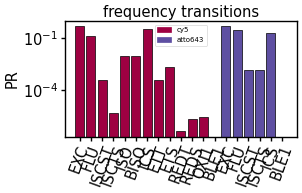

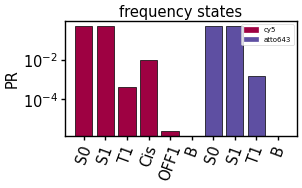

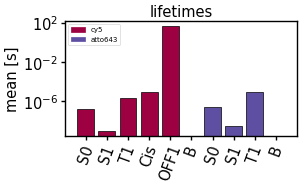

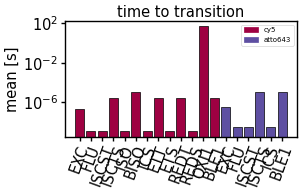

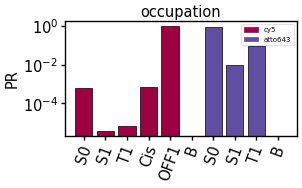

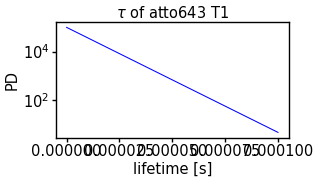

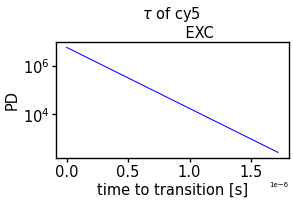

In [35]:
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fl.Fluorophore(name='cy5', position=[0, 0]),
                                                        fl.Fluorophore(name='atto643', position=[0, 2])])
transitions = fluorophore_system.load_transitions(2, 640, True, True, True)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()

prediction = pr.Prediction(transition_set)
mi.print_class(prediction, 'Prediction')

prediction.plot_frequency_transitions(scale=0.5)
prediction.plot_frequency_states(scale=0.5)
prediction.plot_mean_lifetimes(scale=0.5)
prediction.plot_mean_transition_times(scale=0.5)
prediction.plot_state_occupations(scale=0.5)
prediction.plot_lifetime_distributions(fluorophore='atto643', state_identity=3,
                                       scale=0.5)
prediction.plot_transition_time_distributions(fluorophore='cy5', transition_id=0,
                                              scale=0.5)

### Simulation
simulation.py

In [36]:
simulation = si.Simulation(transition_set)

# basic simulation run for a given number of steps (size)
simulation.run(start_at=None, size=1e7, end_time=None, seed=3, use_memmap=None)

# simulate until it reaches given end_time
#simulation.run(start_at=None, size=1e6, end_time=1e-2, seed=3, use_memmap=None)

# if a lot of steps have to be carried out, the arrays may become too large for RAM
# in that case, use memory maps store on drive
# simulation.run(start_at=None, size=1e6, end_time=None, seed=3, 
#                use_memmap=r'C:\Users\ebert\Desktop\memory maps tests')

mi.print_class(simulation, 'Simulation')

Attributes of Simulation:
.................................................................
transition_set = <src.transitions.TransitionSet object at 0x0000021E24A1B700>
_________________________________________________________________
time_series = array([0.00000000e+00, 2.61628401e-07, 2.6228165... 1.47146865e+00, 1.47146865e+00, 1.47146873e+00])
_________________________________________________________________
transition_series = array([52, 58,  0, ..., 56, 62, 56], dtype=uint32)
_________________________________________________________________
state_series = array([[0, 0, 0, ..., 7, 7, 7],
       [0, 1, 0, ..., 1, 0, 1]], dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________




### Analysis to extract statistics of the simulation
analysis.py \
\
The analysis follows these rules:
- time to transitions of energy transfers are collected only from the donor's point of view
- time to transition of e.g., fluorescence, does not differentiate whether energy transfer was also an option or not
- one energy transfer transition occurrence resembles the transition of the donor and the acceptor
- state lifetimes and occurrences do not differentiate whether energy transfer was involved or not \
\
Note: energy transfer has an impact on true fluorescence lifetime only if the acceptors are truly available. If the potential acceptor is in a non-accepting state, the energy transfer is not available. If multiple fluorophores are potential acceptors, all of their respective rates are taken into account. Depending on the photophysical system, energy transfers may only have a marginal impact on the mean fluorescence lifetime.

Attributes of Analysis:
.................................................................
simulation = <src.simulation.Simulation object at 0x0000021E24185480>
_________________________________________________________________
frequency_transitions = array([4.94887640e-01, 1.32735739e-01, 4.0100373... 1.50791187e-03, 1.98131644e-01, 0.00000000e+00])
_________________________________________________________________
frequency_states = {'atto643': array([0.49924604, 0.49924604, 0.00150791, 0.        ]), 'cy5': array([4.94886774e-01, 4.94886774e-01, 4.0100303...9875e-03,
       1.75110495e-06, 0.00000000e+00])}
_________________________________________________________________
transition_time_distributions = [array([5.13859802e-07, 1.25301073e-07, 1.3393619... 1.09876417e-07, 9.20885341e-08, 1.63709029e-07]), array([7.30131955e-10, 3.59233948e-10, 9.7508101... 8.76542006e-10, 2.38307402e-10, 7.45762896e-11]), array([2.02333261e-10, 1.57542812e-10, 9.2295837...1114e-10, 2.20244045e-10,
      

array([[<Axes: title={'center': '$\\tau$ of cy5 \n            EXC'}, xlabel='time to transition [s]', ylabel='PD'>]],
      dtype=object)

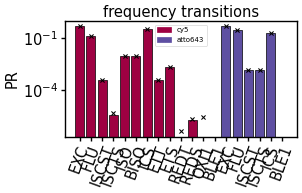

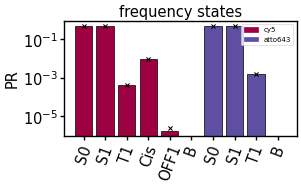

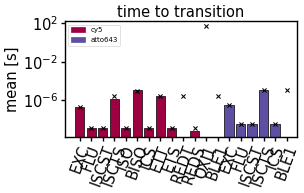

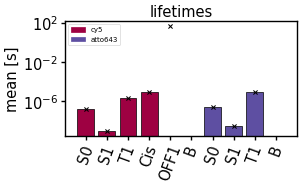

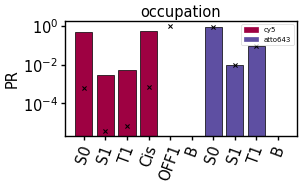

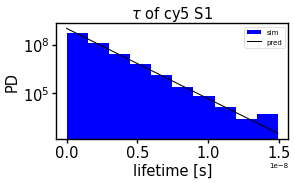

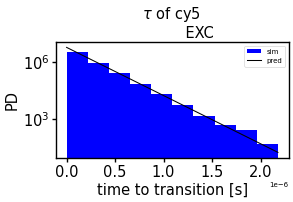

In [37]:
analysis = an.Analysis(simulation=simulation)

mi.print_class(analysis, 'Analysis')

analysis.plot_frequency_transitions(scale=0.5, prediction=prediction)
analysis.plot_frequency_states(scale=0.5, prediction=prediction)
analysis.plot_mean_transition_times(scale=0.5, prediction=prediction)
analysis.plot_mean_lifetimes(scale=0.5, prediction=prediction)
analysis.plot_state_occupations(scale=0.5, prediction=prediction)
analysis.plot_lifetime_distributions(scale=0.5, prediction=prediction, fluorophore='cy5',
                                     state_identity=1)
analysis.plot_transition_time_distributions(scale=0.5, prediction=prediction,
                                            fluorophore='cy5', transition_id=0)


### Simulation (Approximation)
simulation.py

In [40]:
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fl.Fluorophore(name='cy5', position=[0, 0])])
transitions = fluorophore_system.load_transitions(2, 640, True, True, True)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()

prediction = pr.Prediction(transition_set)

approximation = si.Simulation(transition_set=transition_set)
approximation.approximate(prediction=prediction, size=1e7, seed=3)

WARNING for line: prediction = pr.Prediction(transition_set)
 absorbing states have a lifetime of inf and a frequency / occupation of 0. Absorbing transitions have a frequency of 0. 
WARNING for line:             warnings.warn("approximation ignors absorbing states, they will not occur.")
 approximation ignors absorbing states, they will not occur. 


### Simulation (Frames)
simulation.py and emissions.py \
\
Only yields experimentally observable information \
Much less memory consuming \
Subsequent statistical analysis not available \
Subsequent FCS and blinking available

array([[<Axes: title={'center': 'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

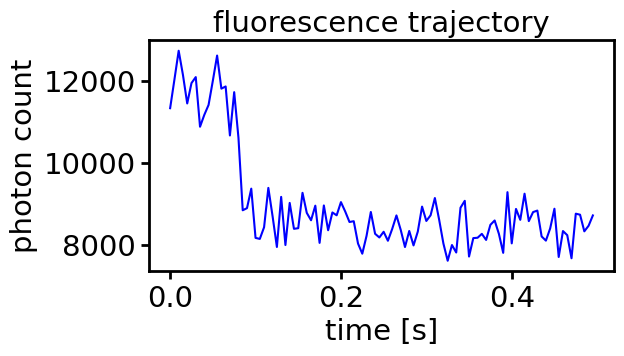

In [22]:
emis = em.Emissions(frame_time='5ms', seed=1, bandpass=(600, 800))
emis.simulate(transition_set=transition_set, seed=9, store_time_points=True, frames=100)
# just like extracted emissions (see below), the follwoing routines can be applied
emis.add_photon_collection_objective(p=0.1)  # 1.
emis.add_quantum_efficiency(p=0.9)  # 3.1.
emis.add_poisson_noise(rate=0.05)  # 3.2. (dark noise), note the frame time
emis.add_emccd_gain(emccd_gain=10)  # 4.
emis.add_gaussian_noise(mean=10, std=1, seed=1)  # 5. (readout noise)

emis.plot_time_series()

### Simulation (GPU)
simulation_GPU.py

In [12]:
import src.simulation_GPU as sigpu
import cupy as cp

# the device ids can differ from the ones displayed in task manager
sigpu.list_devices()

sorted_indic, cumsum = sigpu.prep_direct_method_time(transition_matrix=transition_set_2.transition_matrix)

sorted_indic = cp.asarray(sorted_indic)
cumsum = cp.asarray(cumsum)
row_sums = cp.asarray(transition_set_2.row_sums)
time_series, transition_series = sigpu.direct_method_time(sorted_indic, cumsum, row_sums, size=1000, end_time=1e-3)


pytorch device count: 1
pytorch device: 0
cupy device count: 1
cupy device: 0


### Simulation (parallel)
Not a multi-node-cluster, uses only the cores of the current device \
Multi-node-cluster on windows yet remains unsupported by ray

In [38]:
import ray
ray.shutdown()  # needed to reinitialize ray if executed multiple times
ray.init(runtime_env={'working_dir': src_path})

@ray.remote
def process_parallel(simulation, seed, **simulation_param):
    simulation.run(
        seed=seed, **simulation_param
    )  # @ray.remote can also be used as decorator of class, see ray actors
    time_series = simulation.time_series
    transition_series = simulation.transition_series
    state_series = simulation.state_series

    return time_series, transition_series, state_series

simulation = si.Simulation(transition_set)
seeds = np.arange(4)
# create a 'promise' called futures, which needs to be fetched
futures = [process_parallel.remote(simulation, seed, size=1e3) for seed in seeds]
# fetch 
data = ray.get(futures)

WARNING for line:     from .autonotebook import tqdm as notebook_tqdm
 IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html 
2024-03-13 10:19:41,980	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-03-13 10:19:46,329	INFO worker.py:1715 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2024-03-13 10:20:00,360	INFO packaging.py:530 -- Creating a file package for local directory 'c:\Users\ebert\OneDrive - Universität Würzburg\GitHub\Photoswitching'.
2024-03-13 10:20:00,994	WARNING packaging.py:405 -- File c:\Users\ebert\OneDrive - Universität Würzburg\GitHub\Photoswitching\.git\objects\5d\9c4b6a9b2d54621d9048629e58f4d0210ab40c is very large (12.15MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes': ['c:\Users\ebert\OneDrive - Univers

### Emissions
emissions.py

Attributes of Emissions:
.................................................................
parameters = {'bandpass': (660, 700), 'frame_time': '5ms', 'seed': 100}
_________________________________________________________________
event_time_points = array([4.64951114e-08, 1.26340049e-06, 1.9062213... 1.03091919e+03, 1.03091919e+03, 1.03091920e+03])
_________________________________________________________________
event_time_series[:6] = 0.000    1883.345584
0.005    2075.821618
0.010    1724.330437
0.015     524.696843
0.020      10.905356
0.025      10.446375
dtype: float64
_________________________________________________________________




array([[<Axes: title={'center': 'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

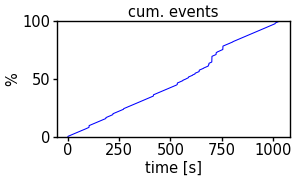

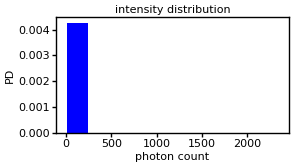

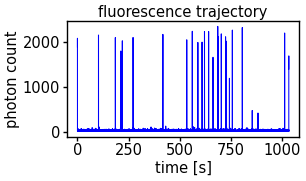

In [44]:
# for multicolor dSTORM, instantiate two Emissions objects with different bandpasses 
emissions = em.Emissions(frame_time='5ms', seed=100, bandpass=(660, 700))
emissions.extract(simulation=approximation)  # 2.
# at this point, the bandpass filter was applied
# yet, the effect of photon collection by the objective is missing
# the order is not relevant for two consecutive binomial distributions
# it is more convenient to apply the bandpass first because it needs the 
# information about the emitting fluorophore whereas all the other effects are
# roughly wavelength independent
emissions.add_photon_collection_objective(p=0.1)  # 1.
emissions.add_quantum_efficiency(p=0.9)  # 3.1.
emissions.add_poisson_noise(rate=0.05)  # 3.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10)  # 4.
emissions.add_gaussian_noise(mean=10, std=1, seed=1)  # 5. (readout noise)

mi.print_class(emissions, 'Emissions')

emissions.plot_cumulative_events(scale=0.5)
emissions.plot_histogram(scale=0.5)
emissions.plot_time_series(scale=0.5)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')

### FCS

fcs.py

Attributes of FCS:
.................................................................
emissions = <src.emissions.Emissions object at 0x0000021E296EBAF0>
_________________________________________________________________
autocorrelation = array([28.02699943, 26.10620412, 24.34097305, 22...96585403,  0.97226277,  0.99092942,  0.98023156])
_________________________________________________________________
tau = array([5.0000e-03, 1.0000e-02, 1.5000e-02, 2.000... 2.4576e+02, 3.2768e+02, 4.9152e+02, 6.5536e+02])
_________________________________________________________________




array([[<Axes: title={'center': '$\\tau_{min} = 5.00e-03$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

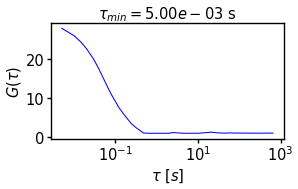

In [46]:
fcs = fcs_p.FCS(emissions)

# autocorrelation via exact time points
fcs.autocorrelate_time_points(exp_min=-10, exp_max=-4, points_per_base=4, base=4, 
                              normalize=True)

# autocorrelation via lag times
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

mi.print_class(fcs, 'FCS')

fcs.plot(normalize_to=None, unit='s', scale=0.5)

# some fcs fits are available:
# fcs_predict = fcs_p.fit_dark(tau, dark_lifetime, dark_occupation)
# fcs_predict = fcs_p.fit_antibunching(tau, excitation_rate, s1_lifetime)
# fcs_predict = fcs_p.fit_triplet_cis(tau, k_isc, k_T, k_01, k_10, k_iso, k_biso_eff)

### Blinking
blinking.py \
\
An ON-period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). An OFF-period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).
Each ON-period is followed by an OFF-period and vice versa.

Attributes of Blinking:
.................................................................
emissions = <src.emissions.Emissions object at 0x0000020E89F0AA70>
_________________________________________________________________
on_periods = []
_________________________________________________________________
off_periods = []
_________________________________________________________________
on_periods_frames = []
_________________________________________________________________
off_periods_frames = []
_________________________________________________________________




WARNING for line:         return n/db/n.sum(), bin_edges
 divide by zero encountered in divide 
WARNING for line:         return n/db/n.sum(), bin_edges
 invalid value encountered in divide 
WARNING for line:     return _methods._mean(a, axis=axis, dtype=dtype,
 Mean of empty slice. 
WARNING for line:             ret = ret.dtype.type(ret / rcount)
 invalid value encountered in scalar divide 


array([[<Axes: xlabel='time [s]'>]], dtype=object)

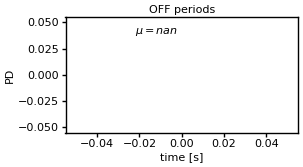

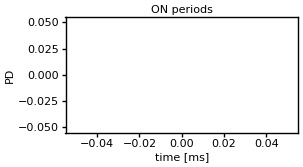

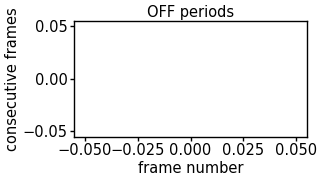

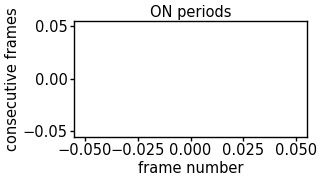

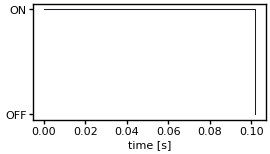

In [13]:
blinks = bl.Blinking(emissions)

mi.print_class(blinks, 'Blinking')

# plot a histogram of OFF times
blinks.plot(mode='off_histogram', density=True, display_mean=True,
            as_time='s', scale=0.5)

# plot a histogram of ON times
blinks.plot(mode='on_histogram', density=True, display_mean=False,
            as_time='ms', scale=0.5)

# plot a time series of OFF times
blinks.plot(mode='off_frame_series', scale=0.5)

# plot a time series of ON times
blinks.plot(mode='on_frame_series', scale=0.5)

# to get information of the photophysical (not analytical) OFF of each fluorophore, use
all_times, values = bl.get_off_statistics(simulation=simulation, index=0, 
                                          event_indices=None)

# plot the photophysical OFF statistics
bl.plot_off_statistics(all_times, values, scale=0.5)

### Multiple plot routines
miscellaneous.py

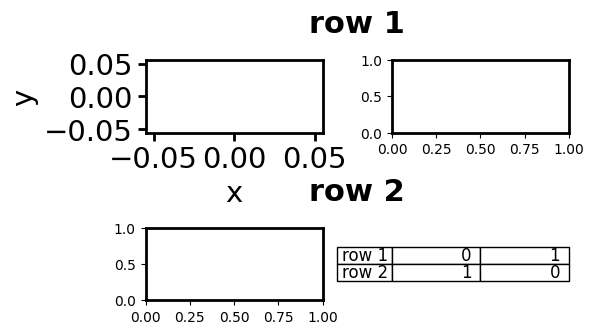

In [14]:
axes = fi.universal_figure(nrows=2, ncols=2)

# get the figure object
figure = mi.get_figure(axes)

# allign the individual plots
figure.tight_layout()

# delete a subplot
mi.delete_subplots(axes, keep_number=3, del_positions=None)

# add row subtitles
mi.create_row_subtitles(axes, nrows=2, ncols=2, titles=['row 1', 'row 2'])

# add a table
mi.add_table(axes, np.array([[0, 1], [1, 0]]), labels=['row 1', 'row 2'], grid=224)